
================ CUSTOMERS DATASET ================

                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  

================ ORDERS DATASET ================

                           order_id             

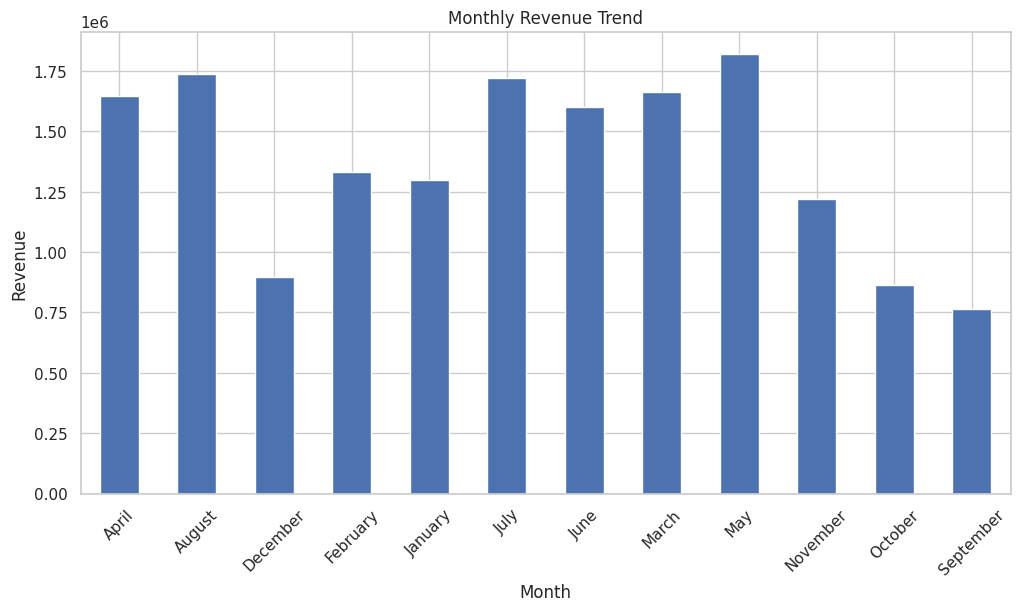


================ TOP PRODUCTS ================

product_category_name_english
health_beauty            1486023.75
watches_gifts            1357478.82
bed_bath_table           1310284.13
sports_leisure           1198524.35
computers_accessories    1095456.98
furniture_decor           946593.12
housewares                820851.24
cool_stuff                750150.02
auto                      712442.08
garden_tools              623851.98
Name: Revenue, dtype: float64


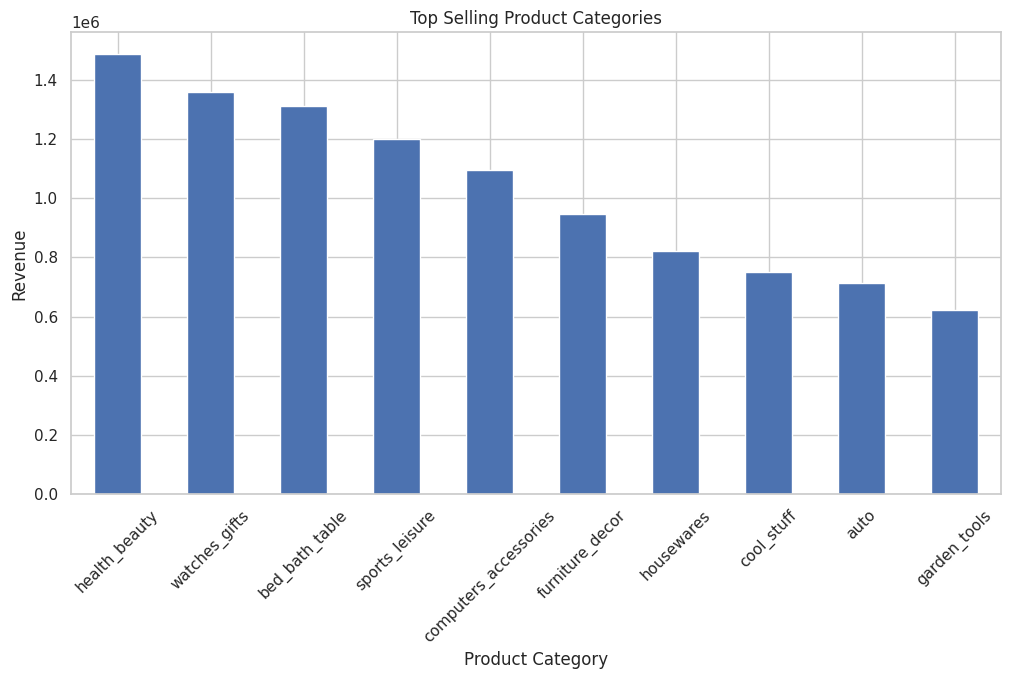


================ PAYMENT METHODS ================

payment_type
credit_card    87286
boleto         23037
voucher         6407
debit_card      1698
not_defined        3
Name: count, dtype: int64


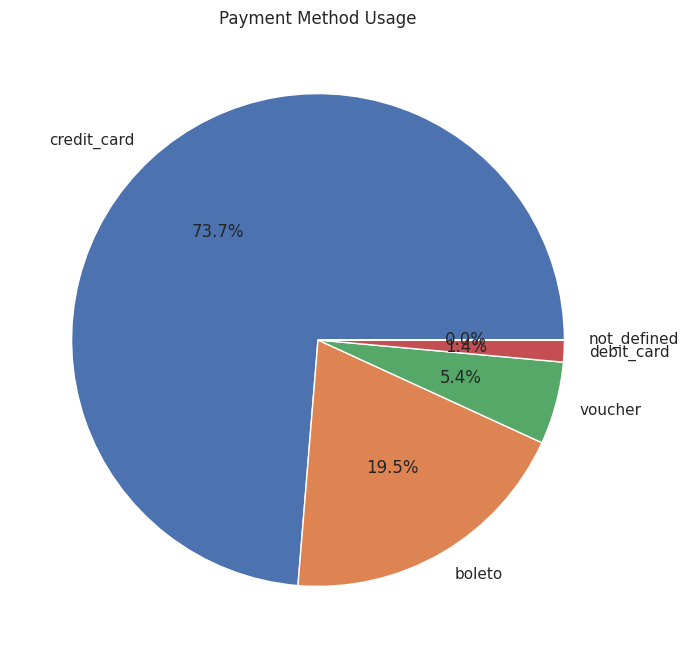


================ TOP STATES ================

customer_state
SP    6201661.39
RJ    2236978.11
MG    1920938.14
RS     929350.22
PR     828526.16
BA     647949.82
SC     630431.81
DF     365186.90
GO     365071.75
ES     335290.50
Name: Revenue, dtype: float64


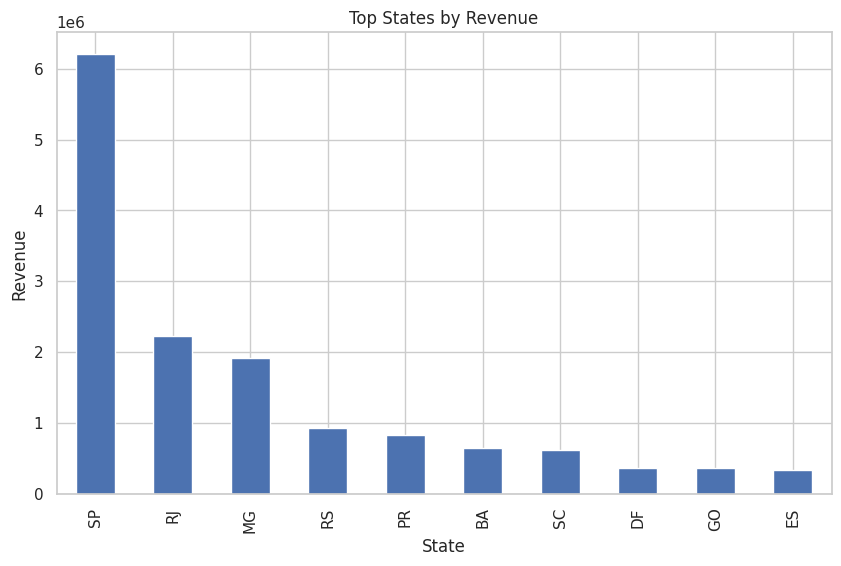


================ ORDER STATUS ================

order_status
delivered      115038
shipped          1245
canceled          745
unavailable       650
processing        375
invoiced          373
created             5
approved            3
Name: count, dtype: int64


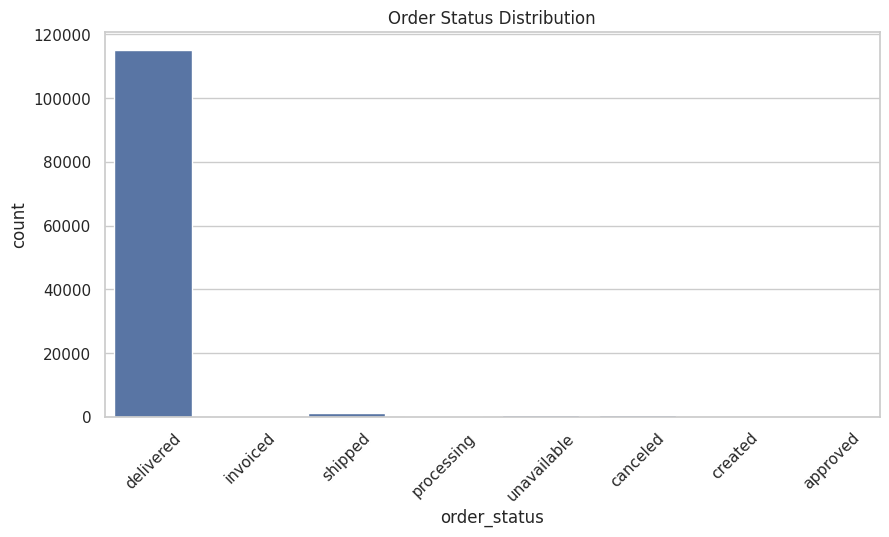


================ REVIEW SCORES ================

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


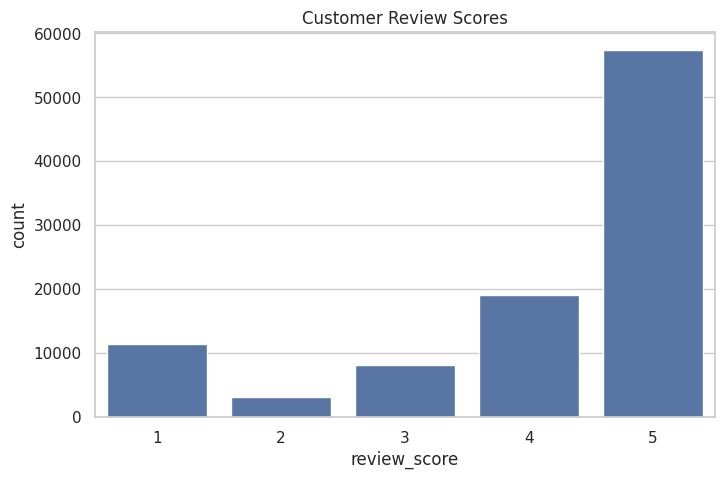

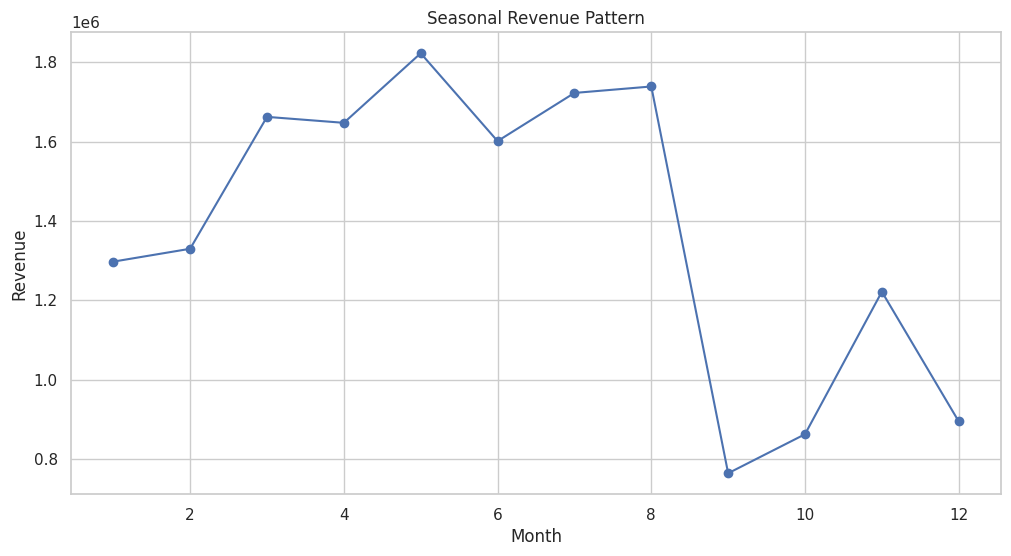

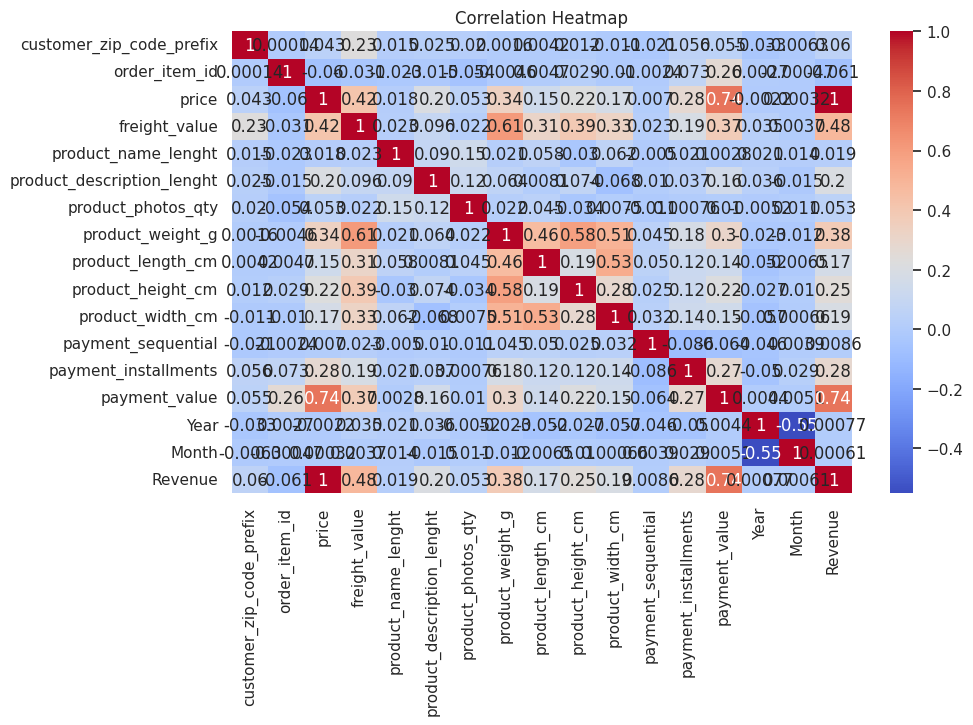


================ TOP CITIES ================

customer_city
sao paulo         2275610.60
rio de janeiro    1201226.55
belo horizonte     430460.60
brasilia           364115.16
curitiba           252659.54
salvador           235547.93
porto alegre       229976.72
campinas           221634.85
guarulhos          175846.45
niteroi            154573.29
Name: Revenue, dtype: float64


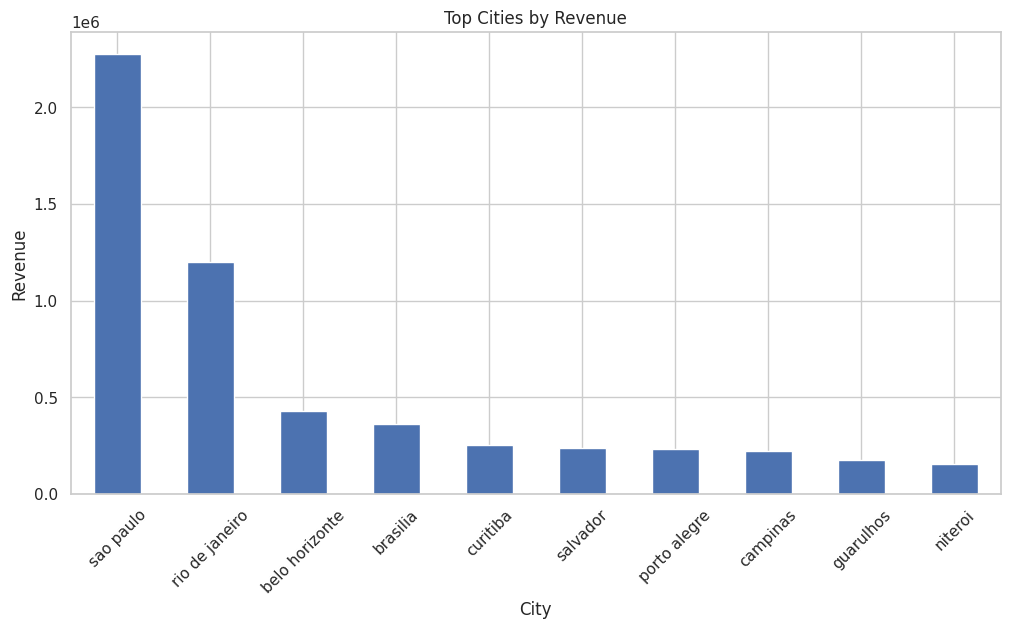


Final Report Saved Successfully!

================ BUSINESS INSIGHTS ================

1. Top product categories generate highest revenue.

2. Monthly trends identify peak shopping periods.

3. Most customers prefer digital payment methods.

4. Certain states contribute highest revenue.

5. Customer reviews indicate customer satisfaction.

6. Seasonal patterns help inventory planning.

7. Revenue analysis helps improve business decisions.


 E-COMMERCE SALES ANALYTICS PROJECT COMPLETED 


In [ ]:
# =========================================================
#        E-COMMERCE SALES ANALYTICS PROJECT
# =========================================================

# =========================================================
# STEP 1 - IMPORT LIBRARIES
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set(style='whitegrid')


# =========================================================
# STEP 2 - LOAD DATASETS
# =========================================================

customers = pd.read_csv("data/olist_customers_dataset.csv")

orders = pd.read_csv("data/olist_orders_dataset.csv")

order_items = pd.read_csv("data/olist_order_items_dataset.csv")

payments = pd.read_csv("data/olist_order_payments_dataset.csv")

products = pd.read_csv("data/olist_products_dataset.csv")

sellers = pd.read_csv("data/olist_sellers_dataset.csv")

reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")

translation = pd.read_csv(
    "data/product_category_name_translation.csv"
)


# =========================================================
# STEP 3 - DISPLAY DATASETS
# =========================================================

print("\n================ CUSTOMERS DATASET ================\n")
print(customers.head())

print("\n================ ORDERS DATASET ================\n")
print(orders.head())

print("\n================ ORDER ITEMS DATASET ================\n")
print(order_items.head())


# =========================================================
# STEP 4 - CHECK MISSING VALUES
# =========================================================

print("\n================ MISSING VALUES ================\n")

print(customers.isnull().sum())

print(orders.isnull().sum())

print(order_items.isnull().sum())


# =========================================================
# STEP 5 - MERGE DATASETS
# =========================================================

df = pd.merge(
    orders,
    customers,
    on='customer_id',
    how='left'
)

df = pd.merge(
    df,
    order_items,
    on='order_id',
    how='left'
)

df = pd.merge(
    df,
    products,
    on='product_id',
    how='left'
)

df = pd.merge(
    df,
    payments,
    on='order_id',
    how='left'
)

df = pd.merge(
    df,
    translation,
    on='product_category_name',
    how='left'
)

print("\nMerged Dataset Shape:", df.shape)


# =========================================================
# STEP 6 - DATA CLEANING
# =========================================================

df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)

df['Year'] = df[
    'order_purchase_timestamp'
].dt.year

df['Month'] = df[
    'order_purchase_timestamp'
].dt.month

df['Month_Name'] = df[
    'order_purchase_timestamp'
].dt.month_name()

df['Revenue'] = (
    df['price'] + df['freight_value']
)

print("\n================ CLEANED DATA ================\n")
print(df.head())


# =========================================================
# STEP 7 - TOTAL REVENUE
# =========================================================

total_revenue = df['Revenue'].sum()

print("\n================ TOTAL REVENUE ================\n")

print("Total Revenue Generated:", total_revenue)


# =========================================================
# STEP 8 - MONTHLY SALES TREND
# =========================================================

monthly_sales = df.groupby(
    'Month_Name'
)['Revenue'].sum()

print("\n================ MONTHLY SALES ================\n")
print(monthly_sales)

plt.figure(figsize=(12,6))

monthly_sales.plot(kind='bar')

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()


# =========================================================
# STEP 9 - TOP SELLING PRODUCTS
# =========================================================

top_products = df.groupby(
    'product_category_name_english'
)['Revenue'].sum().sort_values(
    ascending=False
).head(10)

print("\n================ TOP PRODUCTS ================\n")
print(top_products)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top Selling Product Categories")

plt.xlabel("Product Category")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()


# =========================================================
# STEP 10 - PAYMENT METHOD ANALYSIS
# =========================================================

payment_analysis = df[
    'payment_type'
].value_counts()

print("\n================ PAYMENT METHODS ================\n")
print(payment_analysis)

plt.figure(figsize=(8,8))

payment_analysis.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Payment Method Usage")

plt.ylabel("")

plt.show()


# =========================================================
# STEP 11 - TOP STATES BY REVENUE
# =========================================================

state_sales = df.groupby(
    'customer_state'
)['Revenue'].sum().sort_values(
    ascending=False
).head(10)

print("\n================ TOP STATES ================\n")
print(state_sales)

plt.figure(figsize=(10,6))

state_sales.plot(kind='bar')

plt.title("Top States by Revenue")

plt.xlabel("State")

plt.ylabel("Revenue")

plt.show()


# =========================================================
# STEP 12 - ORDER STATUS ANALYSIS
# =========================================================

status_analysis = df[
    'order_status'
].value_counts()

print("\n================ ORDER STATUS ================\n")
print(status_analysis)

plt.figure(figsize=(10,5))

sns.countplot(
    x='order_status',
    data=df
)

plt.title("Order Status Distribution")

plt.xticks(rotation=45)

plt.show()


# =========================================================
# STEP 13 - CUSTOMER REVIEW ANALYSIS
# =========================================================

review_analysis = reviews[
    'review_score'
].value_counts().sort_index()

print("\n================ REVIEW SCORES ================\n")
print(review_analysis)

plt.figure(figsize=(8,5))

sns.countplot(
    x='review_score',
    data=reviews
)

plt.title("Customer Review Scores")

plt.show()


# =========================================================
# STEP 14 - SEASONAL SALES PATTERN
# =========================================================

seasonal_sales = df.groupby(
    'Month'
)['Revenue'].sum()

plt.figure(figsize=(12,6))

plt.plot(
    seasonal_sales.index,
    seasonal_sales.values,
    marker='o'
)

plt.title("Seasonal Revenue Pattern")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()


# =========================================================
# STEP 15 - CORRELATION HEATMAP
# =========================================================

plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()


# =========================================================
# STEP 16 - TOP CITIES
# =========================================================

top_cities = df.groupby(
    'customer_city'
)['Revenue'].sum().sort_values(
    ascending=False
).head(10)

print("\n================ TOP CITIES ================\n")
print(top_cities)

plt.figure(figsize=(12,6))

top_cities.plot(kind='bar')

plt.title("Top Cities by Revenue")

plt.xlabel("City")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()


# =========================================================
# STEP 17 - EXPORT FINAL REPORT
# =========================================================

df.to_csv(
    "Final_Ecommerce_Analytics_Report.csv",
    index=False
)

print("\nFinal Report Saved Successfully!")


# =========================================================
# STEP 18 - BUSINESS INSIGHTS
# =========================================================

print("""
================ BUSINESS INSIGHTS ================

1. Top product categories generate highest revenue.

2. Monthly trends identify peak shopping periods.

3. Most customers prefer digital payment methods.

4. Certain states contribute highest revenue.

5. Customer reviews indicate customer satisfaction.

6. Seasonal patterns help inventory planning.

7. Revenue analysis helps improve business decisions.
""")


# =========================================================
# STEP 19 - PROJECT COMPLETED
# =========================================================

print("\n================================================")
print(" E-COMMERCE SALES ANALYTICS PROJECT COMPLETED ")
print("================================================")